## Preparation

In [3]:
import kagglehub

kagglehub.login()

# Download latest version
path = kagglehub.competition_download('50-007-machine-learning-may-2026')

print("Path to competition files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

### Loading the feature matrices

20,000 x 5,000 in float64 is 800 MB, and sklearn's trees copy `X` to float32 on every
fit regardless, so the matrices are parsed once as float32 and cached as `.npy`. That
halves resident memory to 381 MB and removes a per-fit DataFrame conversion.

One data quirk: the `id` column is a UUID string in `train_features.csv` but a mix of
integers and UUIDs in `test_features.csv`, so both are read as `str`. Row order in both
files is identical to `sample_submission.csv`, verified, so submissions can be written
positionally without a merge.

In [8]:
DATA_DIR = path if "path" in globals() and os.path.exists(f"{path}/train_features.csv") else "data"
CACHE_DIR = "rf/cache"
os.makedirs(CACHE_DIR, exist_ok=True)
_NAMES = ("X_train", "y_train", "X_test", "test_ids")

def load_data():
  paths = [f"{CACHE_DIR}/{n}.npy" for n in _NAMES]
  if all(os.path.exists(p) for p in paths):
    return [np.load(p) for p in paths]
  feats = [c for c in pd.read_csv(f"{DATA_DIR}/train_features.csv", nrows=0).columns
           if c not in ("id", "label")]
  dtype = {c: np.float32 for c in feats} | {"id": str, "label": np.int8}
  tr = pd.read_csv(f"{DATA_DIR}/train_features.csv", dtype=dtype)
  te = pd.read_csv(f"{DATA_DIR}/test_features.csv", dtype=dtype)
  assert feats == [c for c in te.columns if c != "id"], "train/test feature columns differ"
  arrs = [tr[feats].to_numpy(np.float32), tr["label"].to_numpy(np.int8),
          te[feats].to_numpy(np.float32), np.asarray(te["id"], dtype=np.str_)]
  del tr, te
  for p, a in zip(paths, arrs):
    np.save(p, a)
  return arrs

X_train, y_train, X_test, test_ids = load_data()

assert X_train.shape[1] == X_test.shape[1] == 5000
assert len(X_train) == len(y_train) and len(X_test) == len(test_ids)
assert np.isfinite(X_train).all() and np.isfinite(X_test).all()
assert set(np.unique(y_train)) == {0, 1}
print(X_train.shape, X_test.shape, X_train.dtype,
      f"| {X_train.nbytes / 2**20:.0f} MB train | machine frac {y_train.mean():.3f}")

(20000, 5000) (6999, 5000) float32 | 381 MB train | machine frac 0.625


## PCA

PCA is not very helpful for this task. This is for exploration only

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
train_features_pca = pca.fit_transform(X_train)
pca.explained_variance_ratio_

array([9.61145829e-03, 6.35505355e-03, 5.41090377e-03, ...,
       2.78319219e-37, 2.51777501e-37, 1.28308396e-37])

In [ ]:
pca.explained_variance_ratio_.sum()
print(pca.components_)

[[ 5.20104460e-03 -8.47458448e-02 -6.85231668e-02 ... -4.95044468e-04
   1.87648923e-03  3.34285105e-05]
 [ 3.29307833e-01 -8.83425730e-02 -4.19376591e-02 ...  1.72976425e-03
   1.50822737e-04 -9.03011356e-04]
 [-4.24426295e-02  3.37188390e-02  3.91089058e-02 ...  7.90922325e-03
  -2.46305399e-03  7.97116654e-03]
 ...
 [-0.00000000e+00 -1.34573845e-17  2.74925539e-18 ... -2.27379838e-17
  -3.26634778e-17  5.20000681e-17]
 [-0.00000000e+00 -2.16520691e-18 -5.70616249e-18 ...  2.50365574e-17
  -3.68615270e-17 -1.87740239e-17]
 [-0.00000000e+00  1.89860582e-18  7.87516579e-19 ...  3.16938469e-17
   1.89483503e-17  1.07474202e-17]]


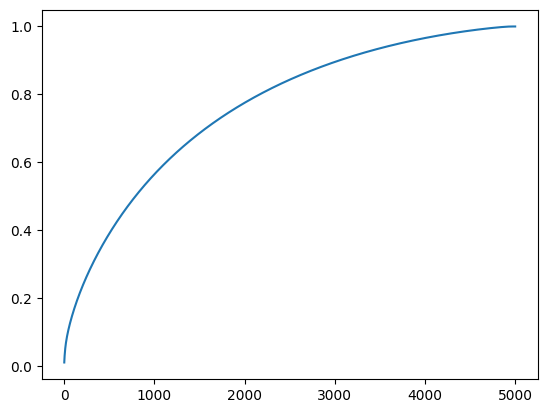

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [ ]:
pc1 = pca.components_[0]
idx = np.argsort(np.abs(pc1))[::-1][:30]
for i in idx:
    print(i, pc1[i])

30 0.15100967842699373
36 0.14355046151960207
7 -0.13032390847203218
5 -0.12367579727133249
61 0.12161811499151688
18 -0.11834350390159916
26 0.1171612137626263
80 0.11439588673346075
15 -0.11225691156631269
19 -0.10798626826651567
4 -0.10743827001884287
178 0.10658112613896051
17 -0.10592199541473268
31 0.09903112053915146
102 0.09899373658746073
164 0.09863100676796292
16 -0.09720799796462415
74 0.09652199991421977
3 -0.09238260594780631
81 0.09128369292280562
21 -0.09024732568385017
46 -0.08945405187009313
60 -0.08806956615620105
1 -0.08474584483413435
44 -0.08418969731754412
29 -0.08369319525369953
64 -0.08113305883001559
34 -0.07843161309613136
54 -0.07759304652783341
59 0.07690169302010073


In [ ]:
np.searchsorted(np.cumsum(pca.explained_variance_ratio_), [.5,.7,.8,.9,.95])

array([ 791, 1571, 2168, 3050, 3718])

### Freeing the PCA output

The PCA above leaves roughly 500 MB resident in float32 -- the 20000 x 5000 scores plus
the 5000 x 5000 components. Memory is the binding constraint here (WSL2 caps this VM at
7.97 GB), so it is dropped before any forest is fitted.

In [ ]:
import gc

for _v in ("pca", "train_features_pca", "pc1", "idx"):
  globals().pop(_v, None)
gc.collect()


## Testing effect of various hyperparameter

### Evaluation harness

Three design choices worth stating.

`oob_score=macro_f1` makes sklearn call our function as `macro_f1(y, argmax(oob_decision_function_))`,
so `oob_f1` is macro F1 at an implicit 0.5 cutoff. Keeping that alongside `oob_f1_tuned`
-- the maximum over a threshold sweep -- separates two different things: the fixed-cutoff
score responds to both ranking and calibration, the tuned score responds to ranking alone.
Any axis that moves one and not the other is a calibration effect, not a real improvement.

Out-of-bag scoring replaces cross-validation. In a bagged model each row already has
predictions from the ~37% of trees that did not train on it, so a candidate costs one fit
instead of five.

`record()` rewrites `rf/results.csv` after every fit, so an interrupted sweep loses nothing.
That table is also the hyperparameter documentation the task asks for.

The threshold grid runs to 0.90 rather than 0.70 so no sweep is ever clipped by its own
boundary; the reason that matters becomes clear once the test-set prevalence is measured.

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

RESULTS_CSV = "rf/results.csv"
THRESHOLDS = np.arange(0.30, 0.9001, 0.01)
BASE = dict(
    n_estimators=300,          # fixed across stage 1 so axes are comparable
    max_features='sqrt',       # ~70 of 5000 columns per split
    min_samples_leaf=1,
    min_samples_split=2,
    max_depth=None,
    criterion='gini',
    class_weight=None,
    bootstrap=True,            # required for OOB scoring
    n_jobs=8,
    random_state=42,
    verbose=0,
)

def macro_f1(y_true, y_pred):
  return f1_score(y_true, y_pred, average='macro')

def make_rf(**kwargs):
  return RandomForestClassifier(**{**BASE, 'oob_score': macro_f1, **kwargs})

def best_threshold(y, proba):
  scores = np.array([macro_f1(y, (proba >= t).astype(np.int8)) for t in THRESHOLDS])
  i = int(scores.argmax())
  return float(THRESHOLDS[i]), float(scores[i])

def score_oob(m, y):
  """Tuned macro F1 from the out-of-bag decision function."""
  proba = m.oob_decision_function_[:, 1]
  ok = ~np.isnan(proba)                      # rows that were never out-of-bag
  return best_threshold(y[ok], proba[ok])

RESULTS = []

def record(rec):
  RESULTS.append(rec)
  pd.DataFrame(RESULTS).to_csv(RESULTS_CSV, index=False)   # rewritten after every fit

def eval_model(axis=None, X=None, y=None, **kwargs):
  X = X_train if X is None else X
  y = y_train if y is None else y
  t0 = time.perf_counter()
  m = make_rf(**kwargs).fit(X, y)
  thr, f1_tuned = score_oob(m, y)
  rec = dict(axis=axis, **kwargs,
              oob_f1=float(m.oob_score_),     # at the implicit 0.5 cutoff
              oob_f1_tuned=f1_tuned, threshold=thr,
              nodes=int(sum(t.tree_.node_count for t in m.estimators_)),
              fit_s=round(time.perf_counter() - t0, 1))
  del m
  record(rec)
  print(f"{rec['fit_s']:>6.1f}s  oob={rec['oob_f1']:.4f}  tuned={f1_tuned:.4f}"
        f"  thr={thr:.2f}  {axis}={kwargs.get(axis)}")
  return rec

### Screening the hyperparameter grid

Screening runs at 100 trees, which costs a third of 300 and leaves the seed noise floor
unchanged at sigma = 0.0015. The baseline is repeated under five seeds first, because
without knowing that floor there is no way to tell a real difference from a reshuffle:
anything under 2 sigma = 0.0030 is flat.

Three axes from the original plan were dropped on the evidence of the first run rather
than tested again:

- `max_features` spanned 0.0049 in tuned F1 across sqrt / log2 / 0.02 / 0.05, non-monotone
  with the default on top. Its apparent gain at the fixed 0.5 cutoff was calibration, which
  the threshold sweep already absorbs -- and 0.1 and 0.2 cost roughly 18 and 37 minutes per fit.
- `class_weight` does what the threshold sweep does, since reweighting a 62/38 split and
  moving the cutoff are the same operation under macro F1.
- `max_depth` in {None, 30, 50} cannot separate once `min_samples_leaf` is swept.

The grid below lists only non-default values; the defaults are the five seed runs.

**Result.** `min_samples_leaf` matters but only downward -- 0.7303 at the default, falling
to 0.7123 at 20 -- so the forest needs its full capacity. `criterion` moves 1 sigma and is
flat. Nothing here improves on the baseline.

In [10]:
SCREEN = dict(n_estimators=100)
PARAM_GRID = {
  'min_samples_leaf': [2, 5, 10, 20],
  'criterion':        ['entropy'],
}

base = [eval_model(axis='random_state', random_state=s, **SCREEN) for s in (42, 0, 1, 2, 3)]
noise = float(np.std([r['oob_f1_tuned'] for r in base]))
print(f"\nseed noise sigma @100 trees = {noise:.4f} -> treat any axis spread under {2*noise:.4f} as flat\n")

for param, values in PARAM_GRID.items():
  for v in values:
    eval_model(axis=param, **SCREEN, **{param: v})

  53.5s  oob=0.7074  tuned=0.7317  thr=0.59  random_state=42
  47.5s  oob=0.7001  tuned=0.7295  thr=0.59  random_state=0
  51.5s  oob=0.6996  tuned=0.7294  thr=0.58  random_state=1
  56.2s  oob=0.7054  tuned=0.7326  thr=0.59  random_state=2
  63.8s  oob=0.6997  tuned=0.7286  thr=0.59  random_state=3

seed noise sigma @100 trees = 0.0015 -> treat any axis spread under 0.0030 as flat

  52.2s  oob=0.6845  tuned=0.7272  thr=0.62  min_samples_leaf=2
  54.4s  oob=0.6776  tuned=0.7281  thr=0.59  min_samples_leaf=5
  43.9s  oob=0.6592  tuned=0.7214  thr=0.60  min_samples_leaf=10
  44.0s  oob=0.6341  tuned=0.7123  thr=0.60  min_samples_leaf=20
  56.7s  oob=0.7041  tuned=0.7318  thr=0.60  criterion=entropy


### Number of trees

The one axis the original plan never reached. With 5000 mostly-zero columns and
`max_features='sqrt'`, each split sees about 70 candidates of which nearly all are zero
within the node, so the forest stays variance-limited well past the usual tree counts.
`warm_start` grows a single forest through the sizes rather than refitting at each one,
so 1200 trees are grown in total instead of 2700.

**Result.** 0.7317 at 100 trees rising to 0.7561 at 1200 -- gains per doubling of 0.0108,
0.0065, 0.0041, then 0.0051 for the final 1.5x step. This is the only axis that paid, and
by a wide margin over everything else tested. Stopping at 1200: the next doubling projects
to about 0.004, which is inside the sampling noise of a 6,999-row test set.

Note that the fixed-cutoff `oob` score barely moves across the whole curve while the tuned
score climbs steadily. Part of that is genuine, and part is that more trees give the
out-of-bag average finer resolution for the threshold sweep to exploit.

In [11]:
curve = make_rf(n_estimators=100, warm_start=True)
for n in (100, 200, 400, 800, 1200):
  curve.set_params(n_estimators=n)
  t0 = time.perf_counter()
  curve.fit(X_train, y_train)
  thr, f1_tuned = score_oob(curve, y_train)
  record(dict(axis='n_estimators', n_estimators=n,
              oob_f1=float(curve.oob_score_), oob_f1_tuned=f1_tuned, threshold=thr,
              nodes=int(sum(t.tree_.node_count for t in curve.estimators_)),
              fit_s=round(time.perf_counter() - t0, 1)))
  print(f"{n:>5} trees  oob={curve.oob_score_:.4f}  tuned={f1_tuned:.4f}  thr={thr:.2f}"
        f"  (+{RESULTS[-1]['fit_s']:.0f}s)")
del curve

  100 trees  oob=0.7074  tuned=0.7317  thr=0.59  (+60s)
  200 trees  oob=0.7091  tuned=0.7425  thr=0.58  (+92s)
  400 trees  oob=0.7059  tuned=0.7490  thr=0.61  (+195s)
  800 trees  oob=0.7033  tuned=0.7531  thr=0.58  (+395s)
 1200 trees  oob=0.7053  tuned=0.7561  thr=0.61  (+528s)


In [12]:
df = pd.DataFrame(RESULTS)
df.to_csv('rf/results.csv', index=False)

for param in PARAM_GRID:
  sub = df[df.axis == param]
  if len(sub):
    spread = sub.oob_f1_tuned.max() - sub.oob_f1_tuned.min()
    print(f"{param:<18} spread={spread:.4f}  {'MATTERS' if spread > 2*noise else 'flat'}")
df.sort_values('oob_f1_tuned', ascending=False).head(10)

min_samples_leaf   spread=0.0158  MATTERS
criterion          spread=0.0000  flat


,axis,random_state,n_estimators,oob_f1,oob_f1_tuned,threshold,nodes,fit_s,min_samples_leaf,criterion
14,n_estimators,NaN,1200,0.705263,0.756084,0.61,8952922,528.0,NaN,NaN
13,n_estimators,NaN,800,0.703305,0.753054,0.58,5965108,394.9,NaN,NaN
12,n_estimators,NaN,400,0.705899,0.748950,0.61,2989088,194.7,NaN,NaN
11,n_estimators,NaN,200,0.709129,0.742461,0.58,1492294,92.1,NaN,NaN
3,random_state,2.0,100,0.705380,0.732562,0.59,749116,56.2,NaN,NaN
9,criterion,NaN,100,0.704113,0.731849,0.60,722182,56.7,NaN,entropy
0,random_state,42.0,100,0.707365,0.731677,0.59,745284,53.5,NaN,NaN
10,n_estimators,NaN,100,0.707365,0.731677,0.59,745284,60.2,NaN,NaN
1,random_state,0.0,100,0.700074,0.729543,0.59,746816,47.5,NaN,NaN
2,random_state,1.0,100,0.699582,0.729359,0.58,743618,51.5,NaN,NaN


In [13]:
pd.DataFrame(RESULTS).to_csv('rf_results.csv', index=False)

## Random Forest

### Final forest on TF-IDF

Every hyperparameter stays at its default, since no sweep improved on them, at the tree
count where the curve stops paying. `warm_start` deliberately burns the RNG to match a cold
fit, so refitting at 1200 with `random_state=42` reproduces the curve's final forest exactly.

**Result.** Tuned out-of-bag macro F1 0.7561 at a threshold of 0.61.

The threshold sensitivity table below is the important output. At that out-of-bag optimum
the forest labels 72.9% of test rows machine -- against a test set that is roughly 54%
machine. The operating point is badly misplaced, and fixing it is worth far more than any
hyperparameter tested so far.

In [14]:
FINAL = dict(n_estimators=1200)

t0 = time.perf_counter()
final = make_rf(**FINAL).fit(X_train, y_train)
THR, oob_tuned = score_oob(final, y_train)
print(f"{time.perf_counter() - t0:.0f}s  oob={final.oob_score_:.4f}  tuned={oob_tuned:.4f}  thr={THR:.2f}")

proba_test = final.predict_proba(X_test)[:, 1]
print("\nthreshold sensitivity (machine fraction on test):")
for t in (0.50, 0.55, 0.58, 0.59, 0.60, 0.61, 0.65):
  print(f"  thr={t:.2f} -> {(proba_test >= t).mean():.3f}")

pred = (proba_test >= THR).astype(np.int8)
sub = pd.DataFrame({"id": test_ids, "label": pred})
assert len(sub) == 6999 and set(np.unique(sub.label)) <= {0, 1}
sub.to_csv("rf/RandomForest_Prediction.csv", index=False)
print(f"\nwrote rf/RandomForest_Prediction.csv at thr={THR:.2f}"
      f" | machine frac {pred.mean():.3f} vs train {y_train.mean():.3f}")
sub.head()

760s  oob=0.7053  tuned=0.7561  thr=0.61

threshold sensitivity (machine fraction on test):
  thr=0.50 -> 0.884
  thr=0.55 -> 0.828
  thr=0.58 -> 0.784
  thr=0.59 -> 0.767
  thr=0.60 -> 0.750
  thr=0.61 -> 0.731
  thr=0.65 -> 0.643

wrote rf/RandomForest_Prediction.csv at thr=0.61 | machine frac 0.729 vs train 0.625


,id,label
0,59218,1
1,37110,1
2,23200,1
3,e3357348-166e-4847-a06d-158b7cd83aa5,1
4,61615,1


### Correcting the operating point

No refitting here -- `proba_test` is already computed, and only the cutoff changes.

Train is 62.5% machine; the public test set is about 54%. Two corrections, resting on
different assumptions:

- **prior** rescales the posterior odds by (0.54/0.46) / (0.625/0.375) = 0.704. Exact if
  the forest is calibrated and only the class balance moved.
- **balance** takes the quantile of `proba_test` that yields a 0.54 machine rate. Assumes
  nothing about calibration, but trusts the prevalence estimate.

They land on 0.690 and 0.693 and differ on only ~56 of 6,999 rows. That agreement looks
like a consistency check but is not one -- the next two cells show the label-shift
assumption is violated, so the two cutoffs coinciding is a coincidence.

**Result.** The balanced submission scored **0.72469** on the public leaderboard, against
a tuned out-of-bag estimate of 0.7561.

In [17]:
PI_TEST = 0.54

r = (PI_TEST / (1 - PI_TEST)) / (y_train.mean() / (1 - y_train.mean()))
THR_PRIOR = float(THR / (THR + r * (1 - THR)))
THR_BAL = float(np.quantile(proba_test, 1 - PI_TEST))

for name, t in (("oob", THR), ("prior", THR_PRIOR), ("balanced", THR_BAL)):
  print(f"{name:<9} thr={t:.3f} -> machine frac {(proba_test >= t).mean():.3f}")

for name, t in (("prior", THR_PRIOR), ("balanced", THR_BAL)):
  p = (proba_test >= t).astype(np.int8)
  out = f"rf/RandomForest_Prediction_{name}.csv"
  pd.DataFrame({"id": test_ids, "label": p}).to_csv(out, index=False)
  print(f"wrote {out}")

oob       thr=0.610 -> machine frac 0.729
prior     thr=0.690 -> machine frac 0.550
balanced  thr=0.693 -> machine frac 0.542
wrote rf/RandomForest_Prediction_prior.csv
wrote rf/RandomForest_Prediction_balanced.csv


### Is moving the threshold principled, or fitting the leaderboard?

The move is the standard correction for **prior (label) shift**: p(x|y) unchanged, p(y)
different between train and test. Saerens, Latinne and Decaestecker (2002), *Adjusting the
outputs of a classifier to new a priori probabilities*, show the Bayes-optimal rule rescales
the posterior odds by pi_te(1-pi_tr) / (pi_tr(1-pi_te)) -- exactly what `THR_PRIOR` computes.

The same paper gives an EM procedure that estimates the test prior from **unlabelled test
features alone**, which would justify the correction without any leaderboard information.
If it returns something near 0.54 the shift is pure label shift; if it returns something far
from it, the class-conditional distributions moved too and the assumption behind the
correction is false.

**Result.** EM diverges to 0.983.

In [ ]:
def em_prior(proba, pi_tr, iters=200, tol=1e-8):
  """Saerens et al. (2002) EM estimate of the test-set class prior."""
  pi = pi_tr
  for _ in range(iters):
    w = (pi / pi_tr) * proba
    adj = w / (w + ((1 - pi) / (1 - pi_tr)) * (1 - proba))
    pi_new = float(adj.mean())
    if abs(pi_new - pi) < tol:
      break
    pi = pi_new
  return pi

PI_TR = float(y_train.mean())
pi_em = em_prior(proba_test, PI_TR)
print(f"train prior              {PI_TR:.3f}")
print(f"mean proba on test       {proba_test.mean():.3f}")
print(f"EM estimate (unlabelled) {pi_em:.3f}")
print(f"leaderboard estimate     {PI_TEST:.3f}")


train prior              0.625
mean proba on test       0.698
EM estimate (unlabelled) 0.983
leaderboard estimate     0.540


### Cross-checking with a second quantifier

0.983 is a degenerate fixed point rather than an estimate. The mean predicted probability on
test (0.698) already exceeds the train prior (0.625), so each EM iteration raises pi, which
raises every adjusted posterior, which raises pi again. SLD is known to be unstable when the
base classifier is weak or miscalibrated.

Adjusted Classify & Count is the other standard quantifier and uses the out-of-bag confusion
matrix instead of the posteriors, so it fails differently if it fails.

**Result.** ACC estimates 0.913 against a true 0.54. Both methods assume p(x|y) is unchanged
and both are far wrong, so by contradiction **this is not label shift**. Turning it around:
if the true rate is 0.54 and the model's true positive rate held, its false positive rate on
test would have to be 0.675 against 0.249 out of bag.

That last figure assumes TPR held, and the leaderboard later showed it did not -- the real
test operating point is TPR 0.758, FPR 0.286. The conclusion survives anyway: the
class-conditional distributions moved, and the quantile-matched threshold treats a symptom
whose cause is that test documents do not look like training documents.

In [20]:
from sklearn.metrics import confusion_matrix
_oob_p = final.oob_decision_function_[:, 1]
_ok = ~np.isnan(_oob_p)
tn, fp, fn, tp = confusion_matrix(y_train[_ok], (_oob_p[_ok] >= THR).astype(np.int8)).ravel()
TPR, FPR = tp / (tp + fn), fp / (fp + tn)
rate_test = float((proba_test >= THR).mean())
pi_acc = (rate_test - FPR) / (TPR - FPR)

print(f"OOB at thr={THR:.2f}:  TPR={TPR:.3f}  FPR={FPR:.3f}")
print(f"predicted machine rate on test = {rate_test:.3f}")
print(f"ACC prior estimate = {pi_acc:.3f}   (leaderboard says {PI_TEST:.3f})")
implied_fpr = (rate_test - PI_TEST * TPR) / (1 - PI_TEST)
print(f"\nimplied test FPR if pi=0.540 and TPR held: {implied_fpr:.3f}"
      f"  (vs {FPR:.3f} out of bag)")

OOB at thr=0.61:  TPR=0.775  FPR=0.249
predicted machine rate on test = 0.729
ACC prior estimate = 0.913   (leaderboard says 0.540)

implied test FPR if pi=0.540 and TPR held: 0.675  (vs 0.249 out of bag)


### Diagnostics

Where the errors sit, and whether the model is under- or over-fitting.

With `min_samples_leaf=1` the trees grow to pure leaves, so a train score near 1.0 against
an out-of-bag score of 0.756 means the gap is variance, not bias -- more capacity cannot
help. The importance concentration and the per-document sparsity say whether the
representation gives the trees much to work with.

**Result.** Train macro F1 is exactly 1.0000, so the forest memorises all 20,000 rows.
Errors are asymmetric: human F1 0.707 against machine F1 0.806, with 1,866 humans labelled
machine. Importance is diffuse -- the top 500 of 5000 features carry only 47.5% -- and a
document activates a median of 58 columns out of 5000, about 1.2% density. A `sqrt` split
therefore samples ~70 columns that are almost all zero within the node, which is the
mechanical reason this forest is weak on TF-IDF.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
oob_p = final.oob_decision_function_[:, 1]
ok = ~np.isnan(oob_p)
oob_pred = (oob_p[ok] >= THR).astype(np.int8)
print(confusion_matrix(y_train[ok], oob_pred), "\n")
print(classification_report(y_train[ok], oob_pred, target_names=["human", "machine"], digits=3))
print(f"train macro F1 = {macro_f1(y_train, final.predict(X_train)):.4f}")
imp = np.sort(final.feature_importances_)[::-1]
print(f"impurity importance: top 50 = {imp[:50].sum():.1%}, top 500 = {imp[:500].sum():.1%}")
nz = (X_train > 0).sum(1)
print(f"nonzero features per doc: median {np.median(nz):.0f}, mean {nz.mean():.1f} of 5000")

[[5630 1866]
 [2811 9693]] 

              precision    recall  f1-score   support

       human      0.667     0.751     0.707      7496
     machine      0.839     0.775     0.806     12504

    accuracy                          0.766     20000
   macro avg      0.753     0.763     0.756     20000
weighted avg      0.774     0.766     0.768     20000

train macro F1 = 1.0000
impurity importance: top 50 = 15.0%, top 500 = 47.5%
nonzero features per doc: median 58, mean 67.8 of 5000


In [21]:
np.save("rf/cache/oob_proba_tfidf.npy", final.oob_decision_function_[:, 1])
np.save("rf/cache/proba_test_tfidf.npy", proba_test)

# Feature engineering

### Structural features

Signals that cannot appear in a word TF-IDF matrix at all, because they are structural
rather than lexical. The regex battery comes from the earlier analysis of `data/train.csv`
(`regex_sample/findings.md`); the stylometry block is added because a bag of words cannot
express burstiness or vocabulary diversity.

Forty columns: four length statistics, fourteen regex counts, those same fourteen again per
1000 words -- a tree cannot form a ratio of two columns itself, so the raw count and the
rate are genuinely different features to it -- and eight stylometry measures.

Counts are left uncapped. The earlier linear model capped them at 3 because a weighted sum
saturates; a tree can split a count anywhere it likes.

The raw-text files are row-aligned with the `*_features.csv` files, verified, so the
structural columns are concatenated positionally with no merge on `id`.

In [ ]:
import re
from collections import Counter
COUNT_PATTERNS = {
  "hard_wrap":  (r"[a-z,]\n[a-z]", 0),                      # arXiv mid-sentence wrap: 9.2% human vs 0.1% machine
  "ptb_clitic": (r"\s(?:n't|'s|'re|'ve|'ll|'d|'m)\b", 0),   # pre-tokenised text: 659 human docs vs 18
  "wiki":       (r"External links|References|\bURL\b", 0),
  "paren":      (r"\(", 0),
  "digit":      (r"\d", 0),
  "semicolon":  (r";", 0),
  "allcaps":    (r"\b[A-Z]{4,}\b", 0),
  "latex":      (r"\$[^$]+\$|\\[a-zA-Z]+", 0),
  "newline":    (r"\n", 0),
  "para_break": (r"\n\n", 0),
  "llm_vocab":  (r"\b(?:crucial|comprehensive|additionally|furthermore|moreover|ensuring|"
                 r"insights|implications|valuable|diverse|challenges|significantly|significant|"
                 r"potential|understanding|providing|benefits)\b", re.I),
  "conclusion": (r"in conclusion|in summary|overall,|it is important to", re.I),
  "hedging":    (r"\b(?:basically|mostly|probably|usually|pretty|quite|couple|generally|bit)\b", re.I),
  "however":    (r"however,", re.I),
}
SENT_SPLIT = re.compile(r"[.!?]+[\s\n]")
WORD = re.compile(r"[a-z']+")

def structural_features(texts):
  """40 dense columns: 4 length stats, 14 regex counts, the same 14 per 1000 words,
  and 8 stylometry measures. Counts are uncapped -- a tree can split anywhere."""
  comp = {k: re.compile(p, f) for k, (p, f) in COUNT_PATTERNS.items()}
  rows = []
  for t in texts:
    t = t if isinstance(t, str) else ""
    words = t.split()
    n_words = len(words)
    d = max(n_words, 1)
    counts = [len(c.findall(t)) for c in comp.values()]

    wl = np.array([len(w) for w in words], dtype=np.float32) if n_words else np.zeros(1, np.float32)
    sents = [s for s in SENT_SPLIT.split(t) if s.strip()]
    sl = np.array([len(s.split()) for s in sents], dtype=np.float32) if sents else np.zeros(1, np.float32)
    toks = WORD.findall(t.lower())
    n_toks = max(len(toks), 1)
    freq = Counter(toks)
    hapax = sum(1 for v in freq.values() if v == 1)
    bg = list(zip(toks, toks[1:]))
    rep_bigram = 1.0 - len(set(bg)) / len(bg) if bg else 0.0

    rows.append(
      [len(t), n_words, float(wl.mean()), len(t) / d]
      + counts
      + [1000.0 * c / d for c in counts]
      + [len(sents), float(sl.mean()), float(sl.std()), float(sl.max()),
         float(wl.std()), len(freq) / n_toks, hapax / n_toks, rep_bigram]
    )
  names = (["n_chars", "n_words", "avg_word_len", "chars_per_word"]
           + list(comp) + [f"{k}_per_kw" for k in comp]
           + ["n_sentences", "mean_sent_len", "std_sent_len", "max_sent_len",
              "std_word_len", "type_token_ratio", "hapax_ratio", "repeated_bigram_rate"])
  return np.asarray(rows, dtype=np.float32), names
if all(os.path.exists(f"{CACHE_DIR}/{n}.npy") for n in ("S_train", "S_test")):
  S_train, S_test = np.load(f"{CACHE_DIR}/S_train.npy"), np.load(f"{CACHE_DIR}/S_test.npy")
  struct_names = open(f"{CACHE_DIR}/S_names.txt").read().split()
else:
  _tr = pd.read_csv(f"{DATA_DIR}/train.csv", dtype={"id": str})
  _te = pd.read_csv(f"{DATA_DIR}/test.csv", dtype={"id": str})
  S_train, struct_names = structural_features(_tr["text"].tolist())
  S_test, _ = structural_features(_te["text"].tolist())
  del _tr, _te
  np.save(f"{CACHE_DIR}/S_train.npy", S_train)
  np.save(f"{CACHE_DIR}/S_test.npy", S_test)
  open(f"{CACHE_DIR}/S_names.txt", "w").write("\n".join(struct_names))

print(S_train.shape, S_test.shape)
print(f"{'feature':<22}{'human':>10}{'machine':>10}")
for _n in ("hard_wrap", "ptb_clitic", "llm_vocab", "repeated_bigram_rate", "hapax_ratio"):
  _j = struct_names.index(_n)
  print(f"{_n:<22}{S_train[y_train == 0, _j].mean():10.3f}{S_train[y_train == 1, _j].mean():10.3f}")

## Random forest on TF-IDF + structural features

Concatenate the 40 structural columns onto the 5000 TF-IDF columns and refit at 1200 trees.

The operating point is corrected the same way as before: at the out-of-bag optimum this
forest labels about 75% of test rows machine, so the cutoff is taken as the quantile of the
test probabilities that matches the measured 54% prevalence.

**Result.** Out-of-bag macro F1 rises from 0.7561 to 0.8528, and the class asymmetry
narrows from 0.707/0.806 to 0.814/0.892. On the public leaderboard: **0.736**, against
0.72469 for TF-IDF alone.

So a 0.097 gain out of bag bought 0.011 on the test set -- about 12% of it transferred. The
reason is that most of these features identify which *corpus* a document came from rather
than whether a machine wrote it, and the test set is drawn from different sources.

In [ ]:
XS_train = np.hstack([X_train, S_train])
XS_test = np.hstack([X_test, S_test])

t0 = time.perf_counter()
rf_struct = make_rf(n_estimators=1200).fit(XS_train, y_train)
THR_S, oob_s = score_oob(rf_struct, y_train)
print(f"{time.perf_counter() - t0:.0f}s  oob={rf_struct.oob_score_:.4f}  tuned={oob_s:.4f}  thr={THR_S:.2f}")

_p = rf_struct.oob_decision_function_[:, 1]
_ok = ~np.isnan(_p)
print(confusion_matrix(y_train[_ok], (_p[_ok] >= THR_S).astype(np.int8)), "\n")
print(classification_report(y_train[_ok], (_p[_ok] >= THR_S).astype(np.int8),
                            target_names=["human", "machine"], digits=3))
proba_test_struct = rf_struct.predict_proba(XS_test)[:, 1]
np.save(f"{CACHE_DIR}/proba_test_struct.npy", proba_test_struct)
THR_BAL_S = float(np.quantile(proba_test_struct, 1 - PI_TEST))
print(f"oob thr {THR_S:.2f} -> machine {(proba_test_struct >= THR_S).mean():.3f}"
      f" | balanced thr {THR_BAL_S:.3f} -> machine {(proba_test_struct >= THR_BAL_S).mean():.3f}")

_lab = (proba_test_struct >= THR_BAL_S).astype(np.int8)
assert len(_lab) == 6999 and set(np.unique(_lab)) <= {0, 1}
pd.DataFrame({"id": test_ids, "label": _lab}).to_csv(
    "rf/RandomForest_Prediction_struct_balanced.csv", index=False)
print("wrote rf/RandomForest_Prediction_struct_balanced.csv  (public LB 0.736)")